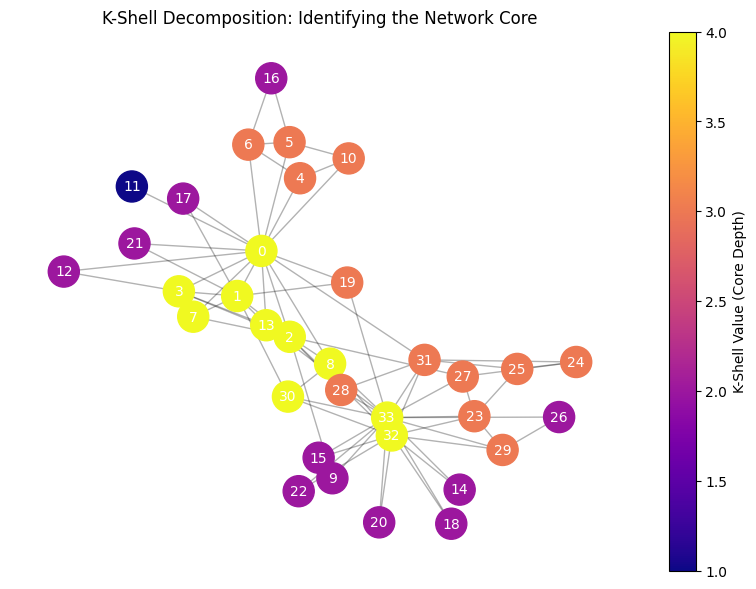

Node | Shell Index
------------------
   7 | 4
  30 | 4
  32 | 4
  33 | 4
   1 | 4
   3 | 4
   8 | 4
  13 | 4
   0 | 4
   2 | 4


In [1]:
import networkx as nx
import matplotlib.pyplot as plt

def k_shell_decomposition(G):
    """
    Performs K-Shell decomposition on a graph.

    Formula/Logic:
    Iteratively remove nodes with degree <= k.
    The 'shell' of a node is the maximum value of k such that the node
    belongs to the k-core but not the (k+1)-core.
    """
    # Copy the graph to avoid modifying the original
    graph = G.copy()
    importance_map = {}
    current_k = 1

    while graph.nodes():
        while True:
            # Calculate degrees of current nodes
            degrees = dict(graph.degree())

            # Find nodes with degree <= current_k
            to_remove = [node for node, deg in degrees.items() if deg <= current_k]

            if not to_remove:
                break

            # Assign the current k-shell value and remove from graph
            for node in to_remove:
                importance_map[node] = current_k
                graph.remove_node(node)

        current_k += 1

    return importance_map

# 1. Create a sample Social Network (Karate Club is a classic example)
G = nx.karate_club_graph()

# 2. Run the Decomposition
shell_results = k_shell_decomposition(G)

# 3. Visualization
plt.figure(figsize=(10, 7))

# Layout for the nodes
pos = nx.spring_layout(G, seed=42)

# Color nodes by their K-shell value
node_colors = [shell_results[node] for node in G.nodes()]

# Draw the network
nodes = nx.draw_networkx_nodes(G, pos,
                               node_size=500,
                               node_color=node_colors,
                               cmap=plt.cm.plasma)

nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, font_size=10, font_color="white")

# Add a colorbar to explain the "Cores"
plt.colorbar(nodes, label='K-Shell Value (Core Depth)')
plt.title("K-Shell Decomposition: Identifying the Network Core")
plt.axis('off')
plt.show()

# Print results
print("Node | Shell Index")
print("-" * 18)
for node, shell in sorted(shell_results.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"{node:4} | {shell}")

Key Concepts Explained

The K-Core: A subgraph where every node has at least degree $k$ within that subgraph.

The Pruning Process: We start at $k=1$. We remove all nodes with only 1 connection. After they are gone, some remaining nodes might now only have 1 connection—we remove those too. We repeat this until no nodes with degree $\leq 1$ remain. Then we move to $k=2$, and so on.

Why it matters: In social networks, "influencers" aren't just people with many followers (high degree); they are often people in the highest K-shell, meaning they are part of a dense, interconnected "inner circle" that controls the flow of information.




What the Visualization Shows

Darker/Lower values: These are "leaf" nodes on the periphery of the network.

Brighter/Higher values: These represent the nucleus of the social network. Even if they don't have the highest total number of edges, they are the most structurally resilient.

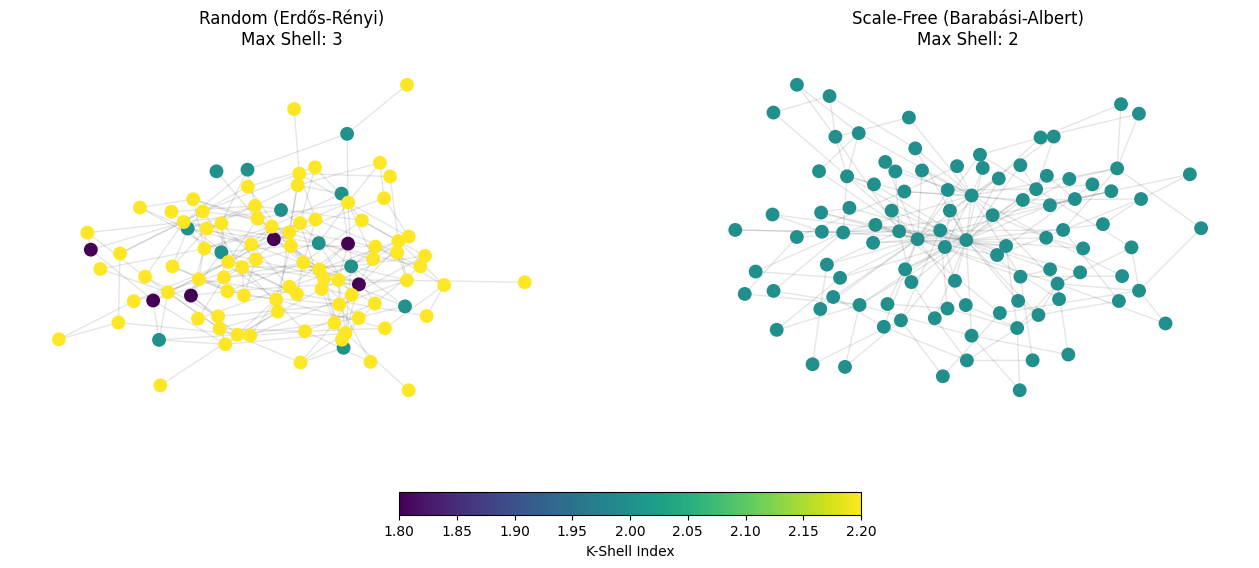

In [2]:
# --- Continuing from the previous script ---

def visualize_topology_comparison():
    n = 100  # Number of nodes
    m = 2    # Number of edges to attach from a new node to existing nodes
    p = 0.05 # Probability for edge creation in random graph

    # 1. Generate Topologies
    # Random Graph: G(n, p) - edges exist with independent probability p
    # Formula for expected average degree: E[k] = p * (n - 1)
    g_random = nx.erdos_renyi_graph(n, p, seed=42)

    # Scale-Free Graph: Power-law degree distribution P(k) ~ k^(-γ)
    # Built via preferential attachment: "The rich get richer"
    g_scalefree = nx.barabasi_albert_graph(n, m, seed=42)

    graphs = [("Random (Erdős-Rényi)", g_random), ("Scale-Free (Barabási-Albert)", g_scalefree)]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for i, (name, G) in enumerate(graphs):
        # Calculate K-Shells using our previous function
        shells = k_shell_decomposition(G)
        max_shell = max(shells.values())

        # Plotting
        pos = nx.spring_layout(G, seed=42)
        nodes = nx.draw_networkx_nodes(G, pos, ax=axes[i],
                                       node_size=80,
                                       node_color=list(shells.values()),
                                       cmap=plt.cm.viridis)
        nx.draw_networkx_edges(G, pos, ax=axes[i], alpha=0.1)

        axes[i].set_title(f"{name}\nMax Shell: {max_shell}")
        axes[i].axis('off')

    plt.colorbar(nodes, ax=axes, label='K-Shell Index', orientation='horizontal', fraction=0.05)
    plt.show()

visualize_topology_comparison()

The core distribution tells a story:

Random graphs tend to have a very uniform core, while Scale-Free graphs (which mimic real social networks like X/Twitter or LinkedIn) often have a small, very dense "elite" core.


Why this matters for "Social Contagion"

Random Networks: A virus or rumor spreads evenly.

Scale-Free Networks: If you "infect" the high K-shell core, the information explodes across the network instantly. If you target the periphery, the rumor usually dies out.